# FoundationStereo 2448 × 2048 离线推理

从 `data/<timestamp>/left.png`、`right.png`、`masks/left_mask.png` 与 `calibration.json` 读取一组原始双目图像。掩码与原始左图对齐，使用相同的左图 rectification map 重映射后用于筛选点云。先运行模型加载单元一次；切换数据时只需要重跑数据、推理和导出单元。不会创建 Open3D 可视化窗口。

## 1. 环境与共用工具

In [1]:
%load_ext autoreload
%autoreload 2

from fs_high_resolution_utils import *
REPO_ROOT, FS_ROOT, DEVICE = bootstrap_notebook(globals())
print('Repository:', REPO_ROOT)
print('GPU:', torch.cuda.get_device_name(DEVICE))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Repository: /home/liu4000/Desktop/FS_Engine
GPU: NVIDIA RTX PRO 4000 Blackwell


## 2. 只加载一次：FoundationStereo 模型

切换时间戳数据时，不需要重新运行本单元。

In [2]:
model, CKPT_PATH = load_foundation_stereo_model(FS_ROOT, DEVICE)
print(f'Model loaded: {CKPT_PATH.name}')
print({k: f'{v:.1f} MiB' for k, v in gpu_memory_mib().items()})

Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
using MLP layer as FFN


Model loaded: model_best_bp2.pth
{'allocated': '1431.9 MiB', 'reserved': '1436.0 MiB', 'peak_allocated': '1431.9 MiB', 'peak_reserved': '1436.0 MiB'}


## 3. 选择一组数据

In [3]:
# 自动使用 data/ 下按路径排序的第一个完整数据组。
CAPTURE_DIR = configure_capture(globals(), REPO_ROOT)
print('Capture:', CAPTURE_DIR)
print('Point cloud directory:', POINT_CLOUD_DIR)
print('Mask:', LEFT_MASK_PATH)

Capture: /home/liu4000/Desktop/FS_Engine/data/Volunteer2_lower/0
Point cloud directory: /home/liu4000/Desktop/FS_Engine/result/Volunteer2_lower/0
Mask: /home/liu4000/Desktop/FS_Engine/data/Volunteer2_lower/0/masks/left_mask.png


## 4. 加载原始图片并进行 stereo rectification

使用保存的 OpenCV-matrix JSON。`rectified_K`、`baseline_m` 和校正后的 `left_mask` 均在同一坐标系，用于后续深度和点云投影。

Rectified: 2448x2048, fx=1723.58, baseline=0.055079 m
Mask: 252,679 / 5,013,504 rectified pixels selected


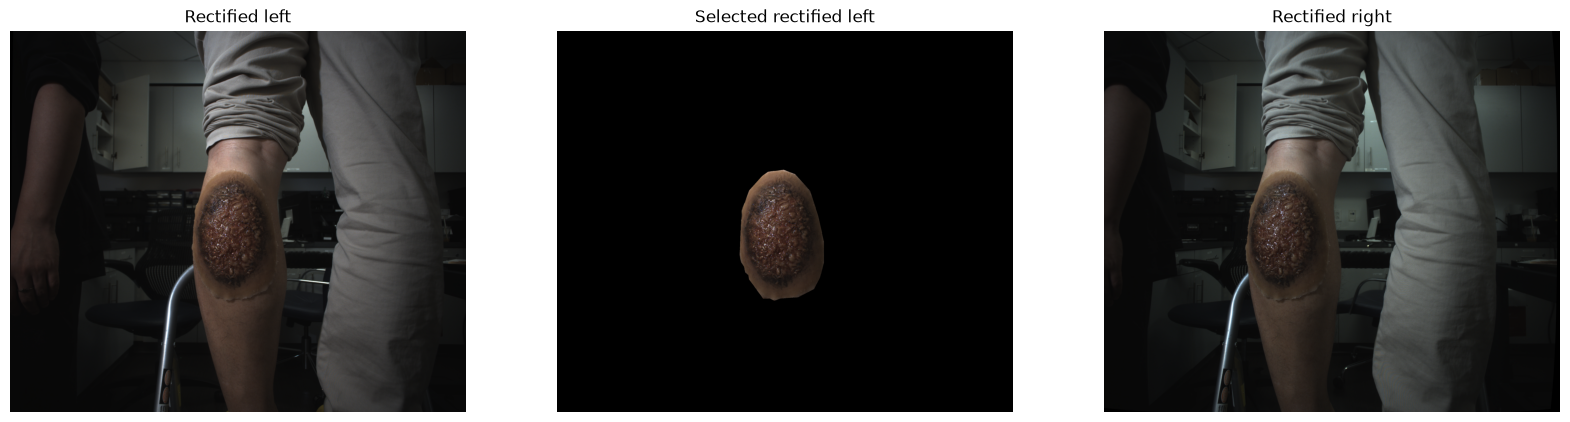

In [4]:
rectified_left, rectified_right, rectified_K, baseline_m, rectified_left_mask = load_rectify_and_select_mask(
    globals(), LEFT_PATH, RIGHT_PATH, LEFT_MASK_PATH, CALIBRATION_PATH, EXPECTED_WIDTH, EXPECTED_HEIGHT
)
print(f'Rectified: {rectified_left.shape[1]}x{rectified_left.shape[0]}, fx={rectified_K[0,0]:.2f}, baseline={baseline_m:.6f} m')
print(f'Mask: {rectified_left_mask.sum():,} / {rectified_left_mask.size:,} rectified pixels selected')
show_rectified_selection(rectified_left, rectified_left_mask, rectified_right)

## 5. 高分辨率 inference：Hiera forward 时间、`init_disp` 与 GPU memory

2448×2048 会先由 `InputPadder` 左右各补 8 px，模型实际输入为 2464×2048。`HIERA=1` 先在一半分辨率推理，再以其视差初始化全分辨率精修。本节会分别在两次 `model.forward` 前后进行 CUDA 同步，从而独立报告半分辨率和全分辨率 forward 耗时；`Inference total` 还包括 Hiera 的缩放、padding 和张量准备。第二次 forward 使用的 1/4 分辨率 `init_disp` 及最终全分辨率 `disparity` 会分别保存为 `result/<capture>/init_disp.tiff` 与 `result/<capture>/disparity.tiff`，两者都是单通道 `float32` TIFF。

In [5]:
VALID_ITERS, HIERA, WARMUP_RUNS = 32, 1, 1

def _timed_forward(*args, **kwargs):
    """Measure one synchronized FoundationStereo.forward call."""
    torch.cuda.synchronize(DEVICE)
    started_at = time.perf_counter()
    output = model.forward(*args, **kwargs)
    torch.cuda.synchronize(DEVICE)
    return output, time.perf_counter() - started_at


def _run_hiera_with_forward_timing():
    """Match run_hierachical while retaining init_disp and both forward timings."""
    height, width = rectified_left.shape[:2]
    left = torch.from_numpy(np.ascontiguousarray(rectified_left)).to(DEVICE, dtype=torch.float32)
    right = torch.from_numpy(np.ascontiguousarray(rectified_right)).to(DEVICE, dtype=torch.float32)
    left, right = left.permute(2, 0, 1)[None], right.permute(2, 0, 1)[None]
    outer_padder = InputPadder(left.shape, divis_by=32, force_square=False)
    left, right = outer_padder.pad(left, right)

    with torch.inference_mode():
        small_ratio = 0.5
        _, _, full_height, full_width = left.shape
        left_small = torch.nn.functional.interpolate(
            left, scale_factor=small_ratio, mode='bilinear', align_corners=False
        )
        right_small = torch.nn.functional.interpolate(
            right, scale_factor=small_ratio, mode='bilinear', align_corners=False
        )
        small_padder = InputPadder(left_small.shape[-2:], divis_by=32, force_square=False)
        left_small, right_small = small_padder.pad(left_small, right_small)
        disparity_small, small_forward_seconds = _timed_forward(
            left_small, right_small, iters=VALID_ITERS, test_mode=True, low_memory=False
        )
        disparity_small = small_padder.unpad(disparity_small.float())
        disparity_small_up = torch.nn.functional.interpolate(
            disparity_small, size=(full_height, full_width), mode='bilinear', align_corners=True
        ) * (1 / small_ratio)
        disparity_small_up = disparity_small_up.clip(0, None)

        full_padder = InputPadder(left.shape[-2:], divis_by=32, force_square=False)
        left, right, disparity_small_up = full_padder.pad(left, right, disparity_small_up)
        disparity_small_up += full_padder._pad[0]
        init_disp = torch.nn.functional.interpolate(
            disparity_small_up, scale_factor=0.25, mode='bilinear', align_corners=True
        ) * 0.25
        disparity, full_forward_seconds = _timed_forward(
            left, right, iters=VALID_ITERS, test_mode=True, low_memory=False, init_disp=init_disp
        )
        disparity = full_padder.unpad(disparity.float())

    disparity = outer_padder.unpad(disparity.float()).squeeze().reshape(height, width)
    return disparity, init_disp, small_forward_seconds, full_forward_seconds


if not HIERA:
    raise ValueError('本节的细分计时和 init_disp 导出需要 HIERA=1。')

for _ in range(WARMUP_RUNS):
    _run_hiera_with_forward_timing()
torch.cuda.synchronize(DEVICE)
torch.cuda.reset_peak_memory_stats(DEVICE)
memory_before_mib = gpu_memory_mib()
started_at = time.perf_counter()
disparity, init_disp, small_forward_seconds, full_forward_seconds = _run_hiera_with_forward_timing()
torch.cuda.synchronize(DEVICE)
inference_seconds = time.perf_counter() - started_at
memory_after_mib = gpu_memory_mib()

init_disp_path = POINT_CLOUD_DIR / 'init_disp.tiff'
init_disp_float32 = np.ascontiguousarray(init_disp.squeeze().detach().cpu().numpy(), dtype=np.float32)
if not cv2.imwrite(str(init_disp_path), init_disp_float32):
    raise RuntimeError(f'Unable to save {init_disp_path}')
saved_init_disp = cv2.imread(str(init_disp_path), cv2.IMREAD_UNCHANGED)
if saved_init_disp is None or saved_init_disp.dtype != np.float32:
    raise RuntimeError(f'{init_disp_path} was not written as float32 TIFF')

disparity_path = POINT_CLOUD_DIR / 'disparity.tiff'
disparity_float32 = np.ascontiguousarray(disparity.detach().cpu().numpy(), dtype=np.float32)
if not cv2.imwrite(str(disparity_path), disparity_float32):
    raise RuntimeError(f'Unable to save {disparity_path}')
saved_disparity = cv2.imread(str(disparity_path), cv2.IMREAD_UNCHANGED)
if saved_disparity is None or saved_disparity.dtype != np.float32:
    raise RuntimeError(f'{disparity_path} was not written as float32 TIFF')

print(f'Inference total: {inference_seconds:.3f} s | hiera={HIERA} | valid_iters={VALID_ITERS}')
print(f'Hiera half-resolution model.forward: {small_forward_seconds:.3f} s')
print(f'Hiera full-resolution model.forward: {full_forward_seconds:.3f} s')
print(f'Hiera model.forward subtotal: {small_forward_seconds + full_forward_seconds:.3f} s')
print('GPU before:', {k: f'{v:.1f} MiB' for k, v in memory_before_mib.items()})
print('GPU after: ', {k: f'{v:.1f} MiB' for k, v in memory_after_mib.items()})
print(f'init_disp: {init_disp_float32.shape}, {init_disp_float32.dtype}, saved: {init_disp_path}')
print(f'disparity: {disparity_float32.shape}, {disparity_float32.dtype}, saved: {disparity_path}')
finite_disparity = disparity[torch.isfinite(disparity)]
print(f'Disparity: {tuple(disparity.shape)}, min={finite_disparity.min().item():.3f}, max={finite_disparity.max().item():.3f}')

Inference total: 8.320 s | hiera=1 | valid_iters=32
Hiera half-resolution model.forward: 1.754 s
Hiera full-resolution model.forward: 6.543 s
Hiera model.forward subtotal: 8.297 s
GPU before: {'allocated': '1463.9 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '1463.9 MiB', 'peak_reserved': '15786.0 MiB'}
GPU after:  {'allocated': '1485.2 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '12258.6 MiB', 'peak_reserved': '15786.0 MiB'}
init_disp: (512, 616), float32, saved: /home/liu4000/Desktop/FS_Engine/result/Volunteer2_lower/0/init_disp.tiff
disparity: (2048, 2448), float32, saved: /home/liu4000/Desktop/FS_Engine/result/Volunteer2_lower/0/disparity.tiff
Disparity: (2048, 2448), min=2.020, max=252.481


## 6. 去噪、Constrained Delaunay 网格与最终导出

视差到深度、`remove_invisible`、距离与 `left_mask.png` 过滤、XYZ 反投影和 3×3 邻域去噪均在 CUDA 上完成。之后在 CPU 的图像 `(u, v)` 平面执行 Constrained Delaunay：原始选区的外轮廓是硬约束，去噪留下的小洞允许由周围有效点跨越。最后仅保存带颜色的三角网格 PLY；不会生成点云 PLY 或打开 Open3D 窗口。

In [9]:
REMOVE_INVISIBLE, DENOISE_CLOUD = True, True
Z_FAR_M = 1.0
DENOISE_MAX_NEIGHBOR_DISTANCE_M, DENOISE_MIN_NEIGHBORS = 0.01, 3
DENOISE_EDGE_MIN_NEIGHBORS = 2
surface = postprocess_disparity_gpu(
    disparity, rectified_K, baseline_m, rectified_left_mask, DEVICE, Z_FAR_M,
    remove_invisible=REMOVE_INVISIBLE, denoise=DENOISE_CLOUD,
    max_neighbor_distance_m=DENOISE_MAX_NEIGHBOR_DISTANCE_M,
    min_neighbors=DENOISE_MIN_NEIGHBORS,
    edge_min_neighbors=DENOISE_EDGE_MIN_NEIGHBORS,
)
xyz_map, point_mask = surface.xyz_map, surface.keep_mask
# Build one mesh for inspection; this cell does not write a PLY file.
DOWNSAMPLE_PIXELS = 4
MESH_MAX_EDGE_M = 0.02
MESH_MAX_DEPTH_JUMP_M = 0.01

mesh_result = build_constrained_mesh(
    xyz_map, point_mask, rectified_left_mask, rectified_left,
    downsample_pixels=DOWNSAMPLE_PIXELS,
    max_edge_m=MESH_MAX_EDGE_M,
    max_depth_jump_m=MESH_MAX_DEPTH_JUMP_M,
)
print(
    f'downsample={DOWNSAMPLE_PIXELS}px | '
    f'area={mesh_result.area_m2:.6f} m² ({mesh_result.area_m2 * 1e4:.2f} cm²) | '
    f'vertices={len(mesh_result.vertices):,} | '
    f'triangles={len(mesh_result.triangles):,}'
)
mesh_path = POINT_CLOUD_DIR / f'mesh.ply'
save_triangle_mesh(mesh_result, mesh_path)
print('Saved:', mesh_path)


downsample=4px | area=0.088146 m² (881.46 cm²) | vertices=87,059 | triangles=169,633
Saved: /home/liu4000/Desktop/FS_realsense/data/example_data/mesh.ply
